## Tutorial: PDEs on curved surfaces

In this tutorial, we solve partial differential equations (PDEs) on a curved triangulated surface (a torus) using `triangulax`. We will cover:

1. **Heat equation** — implicit-Euler time-stepping for diffusion with the cotangent Laplacian and lumped mass matrix.

2. **Non-reciprocal Cahn–Hilliard (NRCH)** — a reaction–diffusion system that exhibits pattern formation.

### Background

On a triangular surface, a PDE can be discretized using the finite element method (FEM). The upshot of the FEM method is that continuous fields are approximated by values at vertices, and operators like the Laplacian get replaced by discretized into matrices. 

The two matrices we will need are $M$, the (diagonal) **mass matrix**, which represents integrating over the region around a vertex, and $L$, the **cotangent Laplacian**, which discretizes the Laplace operator. More detail can be found in Chapter 6 of K. Crane's [Discrete Differential Geometry: An Applied Introduction](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/).

For the heat equation $\partial_t u = D\Delta u$, we can simulate a time step from $t^n$ to $t^{n+1}=t^n+dt$ using the **implicit Euler** method, by solving the equation:

$$(M - dt\, D\, L)\,\mathbf{u}^{n+1} = M\,\mathbf{u}^{n}$$

We use `lineax` for the linear solve and `optimistix` for the nonlinear NRCH system.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import meshplot

from tqdm.notebook import tqdm

In [32]:
import jax
import jax.numpy as jnp

In [12]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [13]:
import lineax
import optimistix

In [14]:
from triangulax import geometry as geom
from triangulax import linops as lin
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
from triangulax.linops import (cotan_laplace_sparse, mass_matrix_sparse,
                               mass_matrix_inv_sparse, diag_jsparse)

### Load mesh and build operators

We load a torus mesh and construct the half-edge connectivity, geometry, and the FEM operators: the cotangent Laplacian $L$ and the lumped mass matrix $M$ (diagonal, with Voronoi dual areas per vertex).

In [15]:
# Load 3D torus mesh
trimesh = TriMesh.read_obj("../test_meshes/torus.obj", dim=3)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

print(f"Torus: {trimesh.vertices.shape[0]} vertices, {trimesh.faces.shape[0]} faces")

# Build FEM operators
L = cotan_laplace_sparse(trimesh.vertices, hemesh)   # cotangent Laplacian (n_vertices x n_vertices)
M = mass_matrix_sparse(trimesh.vertices, hemesh)      # lumped mass matrix
M_inv = mass_matrix_inv_sparse(trimesh.vertices, hemesh)  # inverse mass matrix

Torus: 576 vertices, 1152 faces


  o Torus


In [38]:
# Visualize the torus mesh

meshplot.plot(np.array(trimesh.vertices), np.array(hemesh.faces), shading={"wireframe": False})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

The torus `.obj` file includes UV (texture) coordinates — a 2D parametrization of the surface. We can use these for flat 2D plots of scalar fields, which is often more informative than 3D rendering.

The mapping between mesh vertices and texture vertices is provided by `TriMesh.texture_vertex_to_vertex_map`.

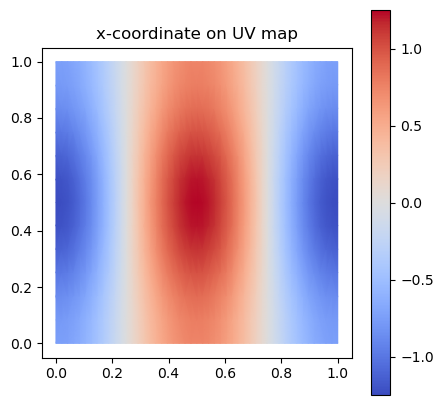

In [17]:
uv = trimesh.texture_vertices                      # (n_texture_vertices, 2)
uv_faces = trimesh.texture_faces                   # (n_faces, 3) — indices into uv
tv2v = trimesh.texture_vertex_to_vertex_map        # texture_vertex_i  ->  mesh_vertex_j

# Helper: map per-vertex scalar field to UV space and plot
def plot_uv(field, ax=None, **kwargs):
    """Plot a per-vertex scalar field on the UV parametrization."""
    ax = ax or plt.gca()
    return ax.tripcolor(np.array(uv[:, 0]), np.array(uv[:, 1]),
                        np.array(field[tv2v]), triangles=np.array(uv_faces),
                        shading='gouraud', **kwargs)

# Demo: colour by the x-coordinate of the 3D position
fig, ax = plt.subplots(figsize=(5, 5))
plot_uv(trimesh.vertices[:, 0], ax=ax, cmap='coolwarm')
ax.set_aspect("equal"); ax.set_title("x-coordinate on UV map"); plt.colorbar(ax.collections[0], ax=ax)

### Heat equation on a torus

The heat equation $\partial_t u = D \Delta u$ on the surface is discretized as $M\dot{\mathbf{u}} = D\, L\, \mathbf{u}$, where $L$ is the cotangent Laplacian and $M$ is the lumped mass matrix.

**Implicit Euler:** at each time step we solve

$$(M - dt\, D\, L)\; \mathbf{u}^{n+1} = M\; \mathbf{u}^{n}$$

using `lineax.BiCGStab`.

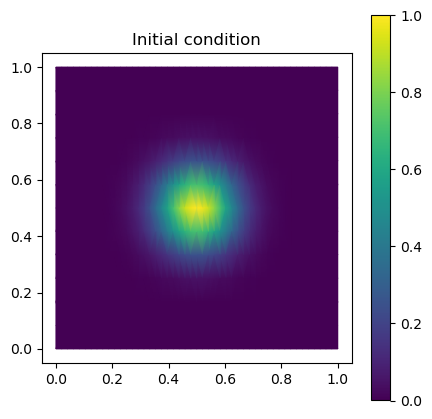

In [18]:
# Parameters
D_heat = 1.0
dt_heat = 0.0001
N_steps_heat = 500

# Initial condition: Gaussian bump centred on a point of the torus.
# We use the UV map to place the bump in the middle of UV space.
uv_vertex = np.array(trimesh.texture_vertices[trimesh.vertex_to_texture_vertex_map])
u0_heat = jnp.exp(-np.linalg.norm(uv_vertex - np.array([0.5, 0.5]), axis=1)**2 / (2 * 0.1**2))

fig, ax = plt.subplots(figsize=(5, 5))
plot_uv(u0_heat, ax=ax, cmap='viridis')
ax.set_aspect("equal"); ax.set_title("Initial condition"); plt.colorbar(ax.collections[0], ax=ax)

In [34]:
# Set up the implicit-Euler linear operator:  A = M - dt*D*L
# We wrap it as a lineax FunctionLinearOperator so we can use iterative solvers.

A_heat_op = lineax.FunctionLinearOperator(
    lambda u: M @ u - dt_heat * D_heat * (L @ u),
    input_structure=jax.ShapeDtypeStruct(u0_heat.shape, u0_heat.dtype),
    tags=lineax.positive_semidefinite_tag)

solver_heat = lineax.BiCGStab(rtol=1e-10, atol=1e-10)

@jax.jit
def heat_step(u):
    """One implicit-Euler step for the heat equation."""
    rhs = M @ u
    return lineax.linear_solve(A_heat_op, rhs, solver=solver_heat, options={"y0": u}).value

In [35]:
#| notest

# Time-stepping loop
u_heat = u0_heat
snapshots_heat = [u_heat]

for t in tqdm(range(N_steps_heat)):
    u_heat = heat_step(u_heat)

snapshots_heat.append(u_heat)

  0%|          | 0/500 [00:00<?, ?it/s]

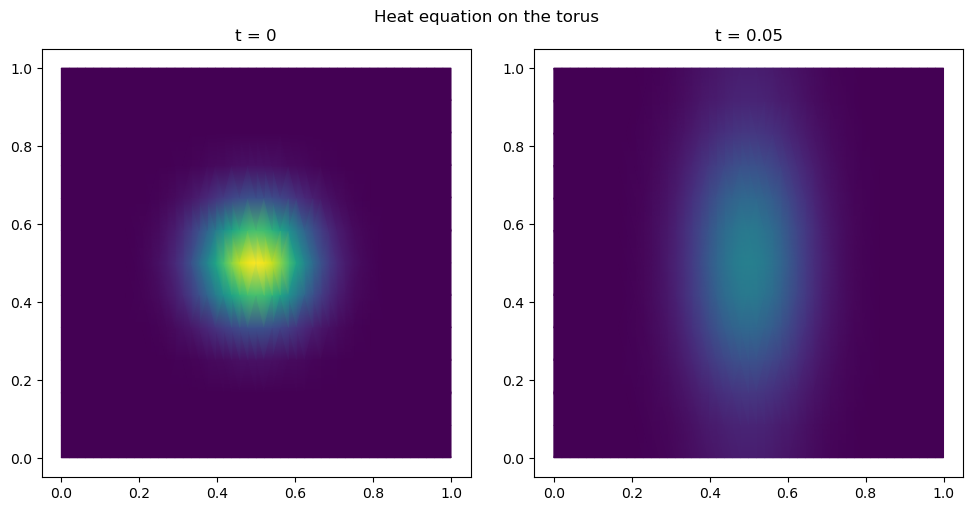

In [36]:
# Visualize the diffusion at t=0 and t=T

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, snap) in zip(axes, [("t = 0", snapshots_heat[0]),
                                     (f"t = {N_steps_heat*dt_heat:.2f}", snapshots_heat[-1])]):
    plot_uv(snap, ax=ax, cmap='viridis', vmin=0, vmax=float(u0_heat.max()))
    ax.set_aspect("equal"); ax.set_title(label)
plt.suptitle("Heat equation on the torus")
plt.tight_layout()

In [37]:
# 3D view of the heat equation solution

norm = mcolors.Normalize(vmin=0, vmax=float(u0_heat.max()))
meshplot.plot(np.array(trimesh.vertices), np.array(hemesh.faces), c=plt.cm.viridis(norm(np.array(snapshots_heat[0])))[:, :3],
              shading={"wireframe": False})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

### Non-reciprocal Cahn–Hilliard (NRCH) on a torus

The NRCH system couples two conserved fields $\phi$ and $\psi$. It is a minimal model for pattern formation [(Brauns and Marchetti, 2024)](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.14.021014):

$$\partial_t \phi = \Delta \mu_\phi, \quad \partial_t \psi = \Delta \mu_\psi$$

with

$$\mu_\phi = -\phi + D\psi + \phi^3 - \Delta\phi, \quad \mu_\psi = |D|\phi + d\,\psi$$

where $D$ controls the non-reciprocal coupling and $d$ is the diffusion coefficient for $\psi$.

Because the $\phi^3$ term makes this nonlinear, we use an implicit-Euler scheme solved with `optimistix.fixed_point` (Newton iteration).

In [39]:
@jax.jit
def nrch_rhs(u, L, M_inv, D, d):
    """RHS of the NRCH equations: M^{-1} L mu.

    Parameters
    ----------
    u : array, shape (2, N)
        Stacked fields [phi, psi].
    L : sparse matrix (N, N)
        Cotangent Laplacian.
    M_inv : sparse matrix (N, N)
        Inverse lumped mass matrix.
    D : float
        Non-reciprocal coupling.
    d : float
        psi diffusion coefficient.

    Returns
    -------
    u_dot : array, shape (2, N)
    """
    phi, psi = u[0], u[1]
    mu_phi = -phi + D * psi + phi**3 - M_inv @ (L @ phi)
    mu_psi = jnp.abs(D) * phi + d * psi
    return jnp.stack([M_inv @ (L @ mu_phi),
                      M_inv @ (L @ mu_psi)])


@jax.jit
def euler_rhs_nrch(u, args):
    """Implicit-Euler fixed-point map for optimistix.fixed_point."""
    u_prev, L, M_inv, dt, D, d = args
    return u_prev + dt * nrch_rhs(u, L, M_inv, D, d)

In [40]:
# NRCH parameters
D_nrch = -0.2
d_nrch = 0.1
phi_bar = 0.0
dt_nrch = 0.1
N_steps_nrch = 5000

# Scale mesh for appropriate spatial scale (matches legacy notebook)
vertices_scaled = trimesh.vertices * 10
L_nrch = cotan_laplace_sparse(vertices_scaled, hemesh)
M_nrch = mass_matrix_sparse(vertices_scaled, hemesh)
M_inv_nrch = mass_matrix_inv_sparse(vertices_scaled, hemesh)
N_grid = vertices_scaled.shape[0]

# Solver
linear_solver = lineax.BiCGStab(rtol=1e-5, atol=1e-5)
solver_nrch = optimistix.Newton(rtol=1e-5, atol=1e-5, linear_solver=linear_solver)
solver_args = (L_nrch, M_inv_nrch, dt_nrch, D_nrch, d_nrch)

@jax.jit
def nrch_step(u_prev):
    """One implicit-Euler step for NRCH."""
    return optimistix.fixed_point(euler_rhs_nrch, solver_nrch, u_prev,
                                  args=(u_prev,) + solver_args).value

# Initial condition: sinusoidal perturbation
uv_v = np.array(trimesh.texture_vertices[trimesh.vertex_to_texture_vertex_map])
u0_nrch = jnp.stack([jnp.sin(2 * jnp.pi * uv_v[:, 0]),
                      jnp.cos(2 * jnp.pi * uv_v[:, 0])])
u0_nrch = u0_nrch.at[0].set(u0_nrch[0] - jnp.mean(u0_nrch[0]) + phi_bar)
u0_nrch = u0_nrch.at[1].set(u0_nrch[1] - jnp.mean(u0_nrch[1]))

print(f"NRCH initial condition shape: {u0_nrch.shape}  (2 fields × {N_grid} vertices)")

NRCH initial condition shape: (2, 576)  (2 fields × 576 vertices)


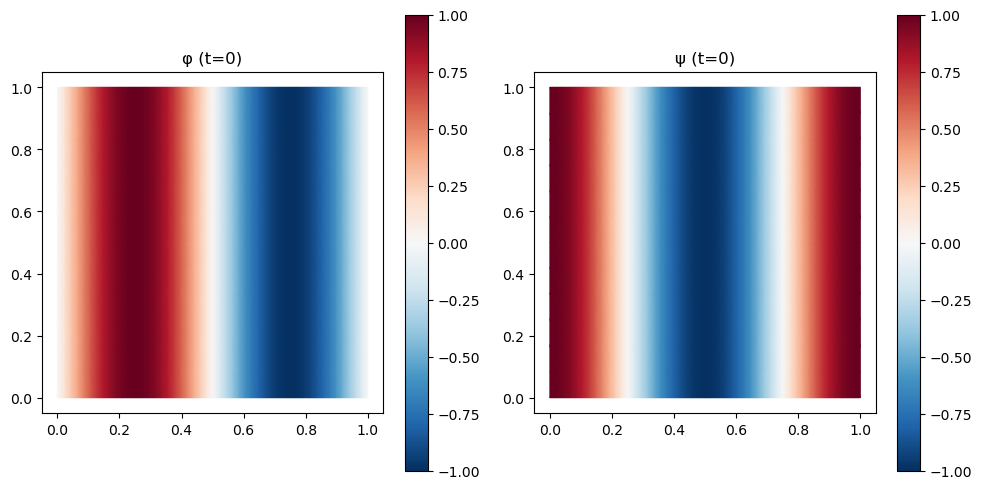

In [41]:
# Plot NRCH initial condition

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, field) in zip(axes, [("φ (t=0)", u0_nrch[0]),
                                      ("ψ (t=0)", u0_nrch[1])]):
    plot_uv(field, ax=ax, cmap='RdBu_r')
    ax.set_aspect("equal"); ax.set_title(label)
    plt.colorbar(ax.collections[0], ax=ax)
plt.tight_layout()

In [42]:
#| notest

# Time-stepping loop for NRCH
u_nrch = u0_nrch

for t in tqdm(range(N_steps_nrch)):
    u_nrch = nrch_step(u_nrch)

  0%|          | 0/5000 [00:00<?, ?it/s]

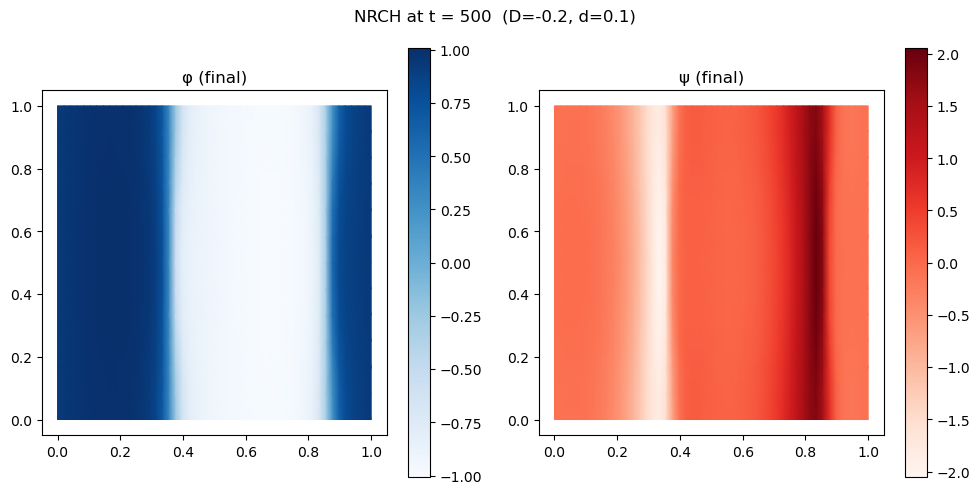

In [43]:
# Final state of NRCH — UV view

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, field, cmap) in zip(axes, [("φ (final)", u_nrch[0], 'Blues'),
                                            ("ψ (final)", u_nrch[1], 'Reds')]):
    plot_uv(field, ax=ax, cmap=cmap)
    ax.set_aspect("equal"); ax.set_title(label)
    plt.colorbar(ax.collections[0], ax=ax)
plt.suptitle(f"NRCH at t = {N_steps_nrch * dt_nrch:.0f}  (D={D_nrch}, d={d_nrch})")
plt.tight_layout()

In [45]:
# Final state of NRCH — 3D view (meshplot)

v_scaled_np = np.array(vertices_scaled)
f_np = np.array(hemesh.faces)

norm_phi = mcolors.Normalize(vmin=float(u_nrch[0].min()), vmax=float(u_nrch[0].max()))
norm_psi = mcolors.Normalize(vmin=float(u_nrch[1].min()), vmax=float(u_nrch[1].max()))

p = meshplot.plot(v_scaled_np, f_np,
                  c=plt.cm.Blues(norm_phi(np.array(u_nrch[0])))[:, :3],
                  shading={"wireframe": False}, return_plot=True)

p.add_mesh(v_scaled_np + np.array([0, 12, 0]), f_np,
           c=plt.cm.Reds(norm_psi(np.array(u_nrch[1])))[:, :3],
           shading={"wireframe": False})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1